In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# !pip -q install -U "pandas==2.2.3" "wfdb==4.3.0"

Device: cuda
Found 54 records.

Loaded 54 RR records (from annotations).

RR scale check (seconds):
  1% / 50% / 99%: 0.4531 / 0.7578 / 1.2031
HR sanity (BPM): min=20.1 mean=81.1 max=295.4

Built 14949 fixed-length samples from 5-minute segments.

Patient-wise split:
  Train patients: 43 | Train samples: 11938
  Test  patients: 11  | Test samples : 3011
Train samples: 11938
RR clamp range (0.5%..99.5%): [0.4453, 1.3203] s


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 001 | D=2.2675 | G=219.7881 | MissMAE(z)=0.4379 | dRRloss(z)=0.4147
Epoch 002 | D=-2.1268 | G=202.8125 | MissMAE(z)=0.4041 | dRRloss(z)=0.3902
Epoch 003 | D=-3.0977 | G=199.3313 | MissMAE(z)=0.3971 | dRRloss(z)=0.3856
Epoch 004 | D=-3.2281 | G=195.4407 | MissMAE(z)=0.3894 | dRRloss(z)=0.3810
Epoch 005 | D=-3.2949 | G=193.2445 | MissMAE(z)=0.3850 | dRRloss(z)=0.3776
Epoch 006 | D=-3.3175 | G=175.4172 | MissMAE(z)=0.3815 | dRRloss(z)=0.3753
Epoch 007 | D=-3.3230 | G=174.1314 | MissMAE(z)=0.3786 | dRRloss(z)=0.3734
Epoch 008 | D=-3.3188 | G=173.6420 | MissMAE(z)=0.3767 | dRRloss(z)=0.3719
Epoch 009 | D=-3.3078 | G=173.0304 | MissMAE(z)=0.3746 | dRRloss(z)=0.3707
Epoch 010 | D=-3.2900 | G=174.0614 | MissMAE(z)=0.3733 | dRRloss(z)=0.3696
Epoch 011 | D=-3.2567 | G=174.0098 | MissMAE(z)=0.3711 | dRRloss(z)=0.3686
Epoch 012 | D=-3.2103 | G=174.7717 | MissMAE(z)=0.3697 | dRRloss(z)=0.3670
Epoch 013 | D=-3.1957 | G=175.3797 | MissMAE(z)=0.3679 | dRRloss(z)=0.3660
Epoch 014 | D=-3.1594 | G=

/tmp/ipykernel_109/69990963.py:182: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pxx[m], f[m])



================== FINAL SUMMARY ==================
Segments evaluated: 200

Signal error (missing points only):
  Avg MAE  = 21.659 ms
  Avg RMSE = 42.317 ms
  Avg RR RelErr (MAE/MeanRR) = 2.763%

HRV metrics: TRUE vs MISSING vs RECOVERED (mean over segments)

  [meanNN_s]
    TRUE mean = 0.793352
    MISS mean = 0.793373 | MISS RelErr% (avg) = 0.316%
    REC  mean = 0.796219 | REC  RelErr% (avg) = 0.434%

  [sdnn_s]
    TRUE mean = 0.0638521
    MISS mean = 0.0637787 | MISS RelErr% (avg) = 8.240%
    REC  mean = 0.0520324 | REC  RelErr% (avg) = 17.351%

  [rmssd_s]
    TRUE mean = 0.0560426
    MISS mean = 0.0431768 | MISS RelErr% (avg) = 19.786%
    REC  mean = 0.0340144 | REC  RelErr% (avg) = 35.993%

  [pnn50_%]
    TRUE mean = 7.37437
    MISS mean = 5.7478 | MISS RelErr% (avg) = 37.254%
    REC  mean = 4.34353 | REC  RelErr% (avg) = 39.234%

  [medianNN_s]
    TRUE mean = 0.796406
    MISS mean = 0.79584 | MISS RelErr% (avg) = 0.218%
    REC  mean = 0.7982 | REC  RelErr% (avg) 

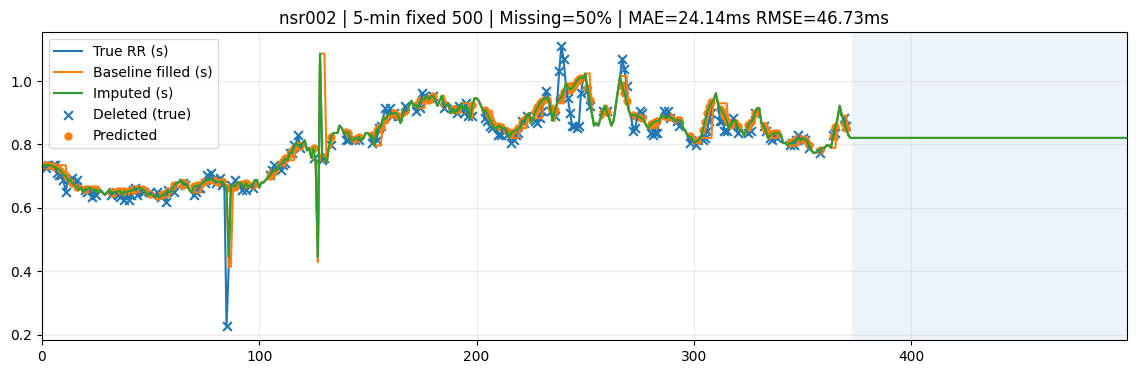

Saved model: /kaggle/working/rr_imputer_5min_wgangp_lstm_residual_seconds_missing30pct.pt


In [3]:
# ============================================================
# KAGGLE FULL NOTEBOOK (ALL-IN-ONE) ✅ FULL MODIFIED VERSION
# RR Interval Imputation on NSRDB RR-Interval DB (nsr2db)
#
# ✅ RR in SECONDS
# ✅ TRUE 5-minute segments (300 seconds)
# ✅ Fixed length (TARGET_LEN beats)
# ✅ LSTM Generator (residual) + WGAN-GP Critic (CNN)
# ✅ Missing-only MAE + physiology dRR loss
# ✅ Missing pattern: RANDOM scattered ONLY
# ✅ Missing rate: 30% of VALID RR points in each sample ✅  (UPDATED)
#
# ✅ EVALUATION UPGRADE (Paper-comparison ready):
#    - RR missing-only: MAE/RMSE (ms) + RelErr% (MAE/MeanRR)
#    - HRV metrics: TRUE vs MISSING vs BASELINES vs IMPUTED
#    - Baselines: ffill, mean, linear interpolation
#    - Recovery Gain % = (|MISS-TRUE| - |REC-TRUE|)/|MISS-TRUE| * 100
#    - Safe relative error floors (pNN50 etc.) to avoid exploding %
#    - Evaluates N segments (default 200) and saves CSV + summary tables
# ============================================================

import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import wfdb

# Optional SciPy (Welch PSD). If missing, freq metrics will be skipped.
try:
    from scipy.signal import welch
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False
    print("⚠️ SciPy not available -> frequency-domain HRV metrics will be skipped.")

# Optional Pandas for nice tables (CSV still saved without pandas)
try:
    import pandas as pd
    PANDAS_OK = True
except Exception:
    PANDAS_OK = False
    print("⚠️ Pandas not available -> will print simple summaries, CSV via csv module.")

import csv
from math import sqrt

# -------------------------
# CONFIG  (SECONDS) ✅ 5-minute segments
# -------------------------
DATASET_ROOT = "/kaggle/input/normal-sinus-dataset/normal-sinus-rhythm-rr-interval-database-1.0.0"

SEG_S        = 300.0   # 5 minutes
TARGET_LEN   = 500     # fixed beats per 5-minute segment
MIN_LEN_KEEP = 200     # discard too-short segments

MISSING_RATE = 0.50    # ✅ 30% missing (of VALID positions)  <<<<<< UPDATED
MIN_MISSING  = 1       # at least 1 missing point

# Generator input baseline fill mode (training/inference input)
FILL_MODE    = "ffill"   # "mean" or "ffill"

# For paper-like comparison baselines during evaluation:
EVAL_BASELINES = ["ffill", "mean", "linear"]  # applied to NaN-masked series

BATCH_SIZE   = 32
EPOCHS       = 30
WARMUP_EPOCHS= 5
N_CRITIC     = 1

LR_G         = 1e-4
LR_D         = 1e-4

LAMBDA_MISS  = 500.0
LAMBDA_DRR   = 2.0
LAMBDA_SMOOTH= 0.0

GP_LAMBDA    = 10.0
SEED         = 42

# Evaluation
EVAL_N_SEGMENTS = 200   # number of test segments to evaluate
EVAL_PLOT_ONE   = True  # plot a single example
EVAL_SAVE_CSV   = True

# -------------------------
# Reproducibility
# -------------------------
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# HRV METRICS (RR in seconds)
# ============================================================
def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def hrv_time_nonlinear(rr_s):
    """
    rr_s: 1D numpy array (seconds), cleaned
    Returns dict of time + nonlinear HRV
    """
    rr = np.asarray(rr_s, dtype=np.float64)
    rr = rr[np.isfinite(rr)]
    rr = rr[(rr > 0.2) & (rr < 3.0)]
    if rr.size < 5:
        return {}

    diff = np.diff(rr)
    diff_ms = diff * 1000.0

    meanNN = np.mean(rr)
    sdnn   = np.std(rr, ddof=1) if rr.size > 1 else 0.0
    rmssd  = np.sqrt(np.mean(diff**2)) if diff.size > 0 else 0.0
    pnn50  = 100.0 * np.mean(np.abs(diff_ms) > 50.0) if diff.size > 0 else 0.0
    medNN  = np.median(rr)
    iqrNN  = np.percentile(rr, 75) - np.percentile(rr, 25)

    # Poincaré SD1/SD2
    sd_diff = np.std(diff, ddof=1) if diff.size > 1 else 0.0
    sd1 = np.sqrt(0.5) * sd_diff
    sd2_sq = max(0.0, 2.0*(sdnn**2) - 0.5*(sd_diff**2))
    sd2 = np.sqrt(sd2_sq)

    return {
        "meanNN_s": _safe_float(meanNN),
        "sdnn_s":   _safe_float(sdnn),
        "rmssd_s":  _safe_float(rmssd),
        "pnn50_%":  _safe_float(pnn50),
        "medianNN_s": _safe_float(medNN),
        "iqrNN_s":    _safe_float(iqrNN),
        "sd1_s": _safe_float(sd1),
        "sd2_s": _safe_float(sd2),
    }

def hrv_freq_welch(rr_s, fs_resample=4.0):
    """
    Frequency HRV using Welch PSD on uniformly resampled tachogram.
    rr_s: seconds
    Returns dict: vlf, lf, hf, lf_hf, total_power (units: s^2)
    """
    if not SCIPY_OK:
        return {}

    rr = np.asarray(rr_s, dtype=np.float64)
    rr = rr[np.isfinite(rr)]
    rr = rr[(rr > 0.2) & (rr < 3.0)]
    if rr.size < 20:
        return {}

    t = np.cumsum(rr)
    t = t - t[0]
    if t[-1] < 30.0:
        return {}

    tu = np.arange(0.0, t[-1], 1.0/fs_resample)
    if tu.size < 64:
        return {}
    rr_u = np.interp(tu, t, rr)

    rr_u = rr_u - np.mean(rr_u)

    nperseg = min(256, rr_u.size)
    f, pxx = welch(rr_u, fs=fs_resample, nperseg=nperseg)

    def band_power(f, pxx, f1, f2):
        m = (f >= f1) & (f < f2)
        if not np.any(m):
            return 0.0
        return np.trapz(pxx[m], f[m])

    vlf = band_power(f, pxx, 0.0033, 0.04)
    lf  = band_power(f, pxx, 0.04,   0.15)
    hf  = band_power(f, pxx, 0.15,   0.40)
    tp  = band_power(f, pxx, 0.0033, 0.40)

    lf_hf = (lf / hf) if hf > 1e-12 else np.nan

    return {
        "vlf_s2": _safe_float(vlf),
        "lf_s2":  _safe_float(lf),
        "hf_s2":  _safe_float(hf),
        "lf_hf":  _safe_float(lf_hf),
        "tp_s2":  _safe_float(tp),
    }

def hrv_all(rr_s):
    out = {}
    out.update(hrv_time_nonlinear(rr_s))
    out.update(hrv_freq_welch(rr_s))
    return out

# ============================================================
# BASELINES on NaN-masked RR (for fair paper-like comparison)
# ============================================================
def apply_missing_mask_numpy(x_true, valid_mask, idx_missing):
    x_missing = x_true.copy().astype(np.float64)
    for i in idx_missing:
        if valid_mask[i] > 0.5:
            x_missing[i] = np.nan
    return x_missing

def fill_ffill_numpy(x_missing, valid_mask):
    x = x_missing.copy()
    idx = np.where(valid_mask > 0.5)[0]
    if idx.size == 0:
        return x
    a, b = idx[0], idx[-1]

    prev = x[a]
    if not np.isfinite(prev):
        j = a
        while j <= b and not np.isfinite(x[j]):
            j += 1
        prev = x[j] if j <= b else 0.0

    for t in range(a, b+1):
        if not np.isfinite(x[t]):
            x[t] = prev
        else:
            prev = x[t]
    return x

def fill_mean_numpy(x_missing, valid_mask):
    x = x_missing.copy()
    idx = np.where(valid_mask > 0.5)[0]
    if idx.size == 0:
        return x
    vals = x[idx]
    m = np.nanmean(vals) if np.isfinite(np.nanmean(vals)) else 0.0
    x[idx] = np.where(np.isfinite(x[idx]), x[idx], m)
    return x

def fill_linear_numpy(x_missing, valid_mask):
    x = x_missing.copy()
    idx = np.where(valid_mask > 0.5)[0]
    if idx.size < 2:
        return x
    a, b = idx[0], idx[-1]
    y = x[a:b+1].copy()

    xi = np.arange(y.size)
    good = np.isfinite(y)
    if good.sum() < 2:
        return fill_mean_numpy(x, valid_mask)

    y_fill = np.interp(xi, xi[good], y[good])
    x[a:b+1] = y_fill
    return x

def apply_eval_baseline(x_missing, valid_mask, method):
    if method == "ffill":
        return fill_ffill_numpy(x_missing, valid_mask)
    if method == "mean":
        return fill_mean_numpy(x_missing, valid_mask)
    if method == "linear":
        return fill_linear_numpy(x_missing, valid_mask)
    raise ValueError("Unknown baseline method: " + str(method))

# ============================================================
# METRIC ERRORS (safe relative error floors to avoid explosion)
# ============================================================
REL_FLOOR_MAP = {
    "pnn50_%": 1.0,    # 1% floor
    "lf_hf":   0.1,    # ratio floor
}

def metric_errors(true_m, est_m, rel_floor_map=None):
    if rel_floor_map is None:
        rel_floor_map = REL_FLOOR_MAP
    errs = {}
    keys = sorted(set(true_m.keys()) & set(est_m.keys()))
    for k in keys:
        tv = true_m[k]
        ev = est_m[k]
        if not (np.isfinite(tv) and np.isfinite(ev)):
            continue
        abs_e = float(abs(ev - tv))
        denom = abs(tv)
        if k in rel_floor_map:
            denom = max(denom, float(rel_floor_map[k]))
        else:
            denom = max(denom, 1e-12)
        rel_e = float(abs_e / denom * 100.0)
        errs[f"{k}__abs"] = abs_e
        errs[f"{k}__rel%"] = rel_e
    return errs

def recovery_gain(err_miss_abs, err_rec_abs, eps=1e-12):
    if not np.isfinite(err_miss_abs) or not np.isfinite(err_rec_abs):
        return np.nan
    if abs(err_miss_abs) < eps:
        return 0.0
    return float((err_miss_abs - err_rec_abs) / abs(err_miss_abs) * 100.0)

# ============================================================
# 1) LOAD RR FROM WFDB ANNOTATIONS (*.ecg as annotation)
# ============================================================
def list_records(dataset_root: str):
    rec_path = os.path.join(dataset_root, "RECORDS")
    if os.path.isfile(rec_path):
        with open(rec_path, "r") as f:
            recs = [ln.strip() for ln in f if ln.strip()]
        return recs
    recs = sorted([fn.replace(".hea", "") for fn in os.listdir(dataset_root) if fn.endswith(".hea")])
    return recs

def load_rr_records_from_wfdb(dataset_root: str, ann_ext="ecg", verbose=True):
    rr_dict, fs_dict = {}, {}
    recs = list_records(dataset_root)
    if verbose:
        print(f"Found {len(recs)} records.")

    for rec in recs:
        try:
            rec_path = os.path.join(dataset_root, rec)
            header = wfdb.rdheader(rec_path)
            fs = float(header.fs) if header.fs is not None else None
            if fs is None:
                raise RuntimeError("Header fs is None")

            ann = wfdb.rdann(rec_path, ann_ext)
            samples = np.asarray(ann.sample, dtype=np.int64)
            if samples.size < 2:
                raise RuntimeError("Not enough annotations")

            rr_s = (np.diff(samples) / fs).astype(np.float32)

            rr_s = rr_s[np.isfinite(rr_s)]
            rr_s = rr_s[(rr_s > 0.2) & (rr_s < 3.0)]

            if rr_s.size < 1000:
                raise RuntimeError(f"Too few RR after cleaning: {rr_s.size}")

            rr_dict[rec] = rr_s
            fs_dict[rec] = fs
        except Exception as e:
            if verbose:
                print(f"Skip {rec}: {e}")

    if verbose:
        print(f"\nLoaded {len(rr_dict)} RR records (from annotations).")
        if len(rr_dict) > 0:
            all_rr = np.concatenate(list(rr_dict.values())).astype(np.float64)
            p1, p50, p99 = np.percentile(all_rr, [1, 50, 99])
            print("\nRR scale check (seconds):")
            print(f"  1% / 50% / 99%: {p1:.4f} / {p50:.4f} / {p99:.4f}")
            hr = 60.0 / all_rr
            print("HR sanity (BPM): min={:.1f} mean={:.1f} max={:.1f}".format(
                np.min(hr), np.mean(hr), np.max(hr)
            ))

    return rr_dict, fs_dict

rr_dict, fs_dict = load_rr_records_from_wfdb(DATASET_ROOT, ann_ext="ecg", verbose=True)
assert len(rr_dict) > 0, "❌ rr_dict empty. Check dataset path + annotation extension."

# ============================================================
# 2) BUILD TRUE 5-MINUTE SEGMENTS
# ============================================================
def split_into_time_segments(rr_s: np.ndarray, seg_s=300.0):
    segments = []
    acc = 0.0
    cur = []
    for v in rr_s:
        v = float(v)
        cur.append(v)
        acc += v
        if acc >= seg_s:
            segments.append(np.asarray(cur, dtype=np.float32))
            acc -= seg_s
            cur = []
    return segments

def make_fixed_length(seg: np.ndarray, target_len=500, min_keep=200):
    L = len(seg)
    if L < min_keep:
        return None, None
    if L >= target_len:
        start = np.random.randint(0, L - target_len + 1)
        x = seg[start:start+target_len].copy()
        valid = np.ones((target_len,), dtype=np.float32)
        return x, valid
    else:
        x = np.empty((target_len,), dtype=np.float32)
        valid = np.zeros((target_len,), dtype=np.float32)
        x[:L] = seg
        valid[:L] = 1.0
        x[L:] = seg[-1]
        return x, valid

segments_by_patient = {}
fixed_samples = []

for pid, rr in rr_dict.items():
    segs = split_into_time_segments(rr, seg_s=SEG_S)
    segments_by_patient[pid] = segs
    for seg in segs:
        x, valid = make_fixed_length(seg, target_len=TARGET_LEN, min_keep=MIN_LEN_KEEP)
        if x is not None:
            fixed_samples.append((pid, x, valid))

print(f"\nBuilt {len(fixed_samples)} fixed-length samples from 5-minute segments.")

# ============================================================
# 3) TRAIN/TEST SPLIT (PATIENT-WISE ✅)
# ============================================================
all_pids = sorted(list(rr_dict.keys()))
random.shuffle(all_pids)

n_train = int(0.8 * len(all_pids))
train_pids = set(all_pids[:n_train])
test_pids  = set(all_pids[n_train:])

train_samples = [(pid,x,v) for (pid,x,v) in fixed_samples if pid in train_pids]
test_samples  = [(pid,x,v) for (pid,x,v) in fixed_samples if pid in test_pids]

print(f"\nPatient-wise split:")
print(f"  Train patients: {len(train_pids)} | Train samples: {len(train_samples)}")
print(f"  Test  patients: {len(test_pids)}  | Test samples : {len(test_samples)}")

# ============================================================
# 4) DATASET + MASKING (30% missing of VALID beats)
# ============================================================
class RR5MinDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        pid, x, valid = self.samples[idx]
        return pid, torch.tensor(x, dtype=torch.float32), torch.tensor(valid, dtype=torch.float32)

def make_mask_and_corrupt_rate(x, valid_mask, missing_rate=0.30, min_missing=1, fill_mode="ffill"):
    """
    Choose ~missing_rate of VALID indices to delete (random scattered).
    Returns:
      x_obs (filled baseline), m (1 observed, 0 missing), idx_missing_list
    """
    B, T = x.shape
    m = torch.ones((B, T), device=x.device)
    idx_missing_list = []

    for b in range(B):
        valid_idx = torch.where(valid_mask[b] > 0.5)[0]
        n_valid = int(valid_idx.numel())
        if n_valid <= 0:
            idx = valid_idx
        else:
            k = int(np.floor(n_valid * float(missing_rate)))
            k = max(int(min_missing), k)
            k = min(k, n_valid)
            perm = valid_idx[torch.randperm(n_valid, device=x.device)]
            idx = perm[:k]

        m[b, idx] = 0.0
        idx_missing_list.append(idx)

    if fill_mode == "mean":
        obs_sum = (x * m).sum(dim=1, keepdim=True)
        obs_cnt = m.sum(dim=1, keepdim=True).clamp(min=1.0)
        fill = obs_sum / obs_cnt
        x_obs = x * m + fill * (1.0 - m)

    elif fill_mode == "ffill":
        x_obs = x.clone()
        for b in range(B):
            missing = (m[b] == 0)
            valid_idx = torch.where(valid_mask[b] > 0.5)[0]
            if valid_idx.numel() == 0:
                continue
            first = int(valid_idx[0].item())
            prev = x_obs[b, first].item()
            for t in range(T):
                if valid_mask[b, t] < 0.5:
                    continue
                if missing[t]:
                    x_obs[b, t] = prev
                else:
                    prev = x_obs[b, t].item()
    else:
        raise ValueError("fill_mode must be 'mean' or 'ffill'")

    return x_obs, m, idx_missing_list

def drr(x):
    dx = x[:, 1:] - x[:, :-1]
    dx = torch.cat([torch.zeros((x.size(0), 1), device=x.device), dx], dim=1)
    return dx

# ============================================================
# 5) MODELS
# ============================================================
class LSTMGeneratorResidual(nn.Module):
    def __init__(self, hidden=96, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=4, hidden_size=hidden, num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=True
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x_base, m, noise):
        dx = drr(x_base)
        inp = torch.stack([x_base, m, dx, noise], dim=-1)
        h, _ = self.lstm(inp)
        delta = self.head(h).squeeze(-1)
        return delta

class CNNWganCritic(nn.Module):
    def __init__(self, channels=64, kernel=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, channels, kernel, padding=kernel//2),
            nn.LeakyReLU(0.2),
            nn.Conv1d(channels, channels, kernel, padding=kernel//2),
            nn.LeakyReLU(0.2),
            nn.Conv1d(channels, channels, kernel, padding=kernel//2),
            nn.LeakyReLU(0.2),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(channels, 1)

    def forward(self, x):
        x = x.unsqueeze(1)
        h = self.net(x)
        h = self.pool(h).squeeze(-1)
        return self.fc(h).squeeze(-1)

def gradient_penalty(critic, real, fake, gp_lambda=10.0):
    B = real.size(0)
    eps = torch.rand(B, 1, device=real.device).expand_as(real)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    scores = critic(x_hat)
    grads = torch.autograd.grad(
        outputs=scores, inputs=x_hat,
        grad_outputs=torch.ones_like(scores),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grads = grads.view(B, -1)
    gp = ((grads.norm(2, dim=1) - 1.0) ** 2).mean() * gp_lambda
    return gp

# ============================================================
# 7) TRAIN
# ============================================================
def train_wgan(train_samples):
    ds = RR5MinDataset(train_samples)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    print("Train samples:", len(ds))

    G = LSTMGeneratorResidual(hidden=96, num_layers=2, dropout=0.1).to(device)
    D = CNNWganCritic(channels=64, kernel=5).to(device)

    opt_g = optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.9))
    opt_d = optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.9))

    all_vals = np.concatenate([x for (_, x, _) in train_samples]).astype(np.float64)
    lo, hi = np.percentile(all_vals, [0.5, 99.5]).astype(np.float32)
    lo, hi = float(lo), float(hi)
    print(f"RR clamp range (0.5%..99.5%): [{lo:.4f}, {hi:.4f}] s")

    for ep in range(1, EPOCHS + 1):
        G.train(); D.train()
        d_sum = g_sum = miss_sum = drr_sum = 0.0

        for _, x_s, valid in dl:
            x_s = x_s.to(device)
            valid = valid.to(device)

            mu  = (x_s * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
            var = (((x_s - mu) ** 2) * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
            std = torch.sqrt(var).clamp(min=1e-6)
            x = (x_s - mu) / std

            # ---- Train critic ----
            for _ in range(N_CRITIC):
                with torch.no_grad():
                    x_base, m, _ = make_mask_and_corrupt_rate(
                        x, valid, missing_rate=MISSING_RATE, min_missing=MIN_MISSING, fill_mode=FILL_MODE
                    )
                    noise = torch.rand_like(x) * (1.0 - m)
                    delta = G(x_base, m, noise)
                    x_hat = m * x + (1.0 - m) * (x_base + delta)
                    x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

                real_score = D(x)
                fake_score = D(x_hat)
                gp = gradient_penalty(D, x, x_hat, gp_lambda=GP_LAMBDA)
                d_loss = (fake_score.mean() - real_score.mean()) + gp

                opt_d.zero_grad(set_to_none=True)
                d_loss.backward()
                opt_d.step()

            # ---- Train generator ----
            x_base, m, _ = make_mask_and_corrupt_rate(
                x, valid, missing_rate=MISSING_RATE, min_missing=MIN_MISSING, fill_mode=FILL_MODE
            )
            noise = torch.rand_like(x) * (1.0 - m)
            delta = G(x_base, m, noise)
            x_hat = m * x + (1.0 - m) * (x_base + delta)
            x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

            adv = -D(x_hat).mean()
            if ep <= WARMUP_EPOCHS:
                adv = 0.0 * adv

            miss_mask = (1.0 - m) * valid
            denom = miss_mask.sum().clamp(min=1.0)
            miss_mae = (torch.abs(x_hat - x) * miss_mask).sum() / denom

            drr_hat = x_hat[:, 1:] - x_hat[:, :-1]
            drr_true = x[:, 1:] - x[:, :-1]
            valid_pair = valid[:, 1:] * valid[:, :-1]
            m_pair = m[:, 1:] * m[:, :-1]
            miss_drr_mask = (1.0 - m_pair) * valid_pair
            denom_drr = miss_drr_mask.sum().clamp(min=1.0)
            drr_loss = (torch.abs(drr_hat - drr_true) * miss_drr_mask).sum() / denom_drr

            smooth = torch.mean(torch.abs(drr_hat) * valid_pair) if LAMBDA_SMOOTH > 0 else torch.tensor(0.0, device=device)

            g_loss = adv + LAMBDA_MISS * miss_mae + LAMBDA_DRR * drr_loss + LAMBDA_SMOOTH * smooth

            opt_g.zero_grad(set_to_none=True)
            g_loss.backward()
            opt_g.step()

            d_sum += float(d_loss.item())
            g_sum += float(g_loss.item())
            miss_sum += float(miss_mae.item())
            drr_sum += float(drr_loss.item())

        print(
            f"Epoch {ep:03d} | D={d_sum/len(dl):.4f} | G={g_sum/len(dl):.4f} | "
            f"MissMAE(z)={miss_sum/len(dl):.4f} | dRRloss(z)={drr_sum/len(dl):.4f}"
        )

    return G, D, lo, hi

# ============================================================
# 8) INFERENCE for one sample (imputed RR + missing idx)
# ============================================================
@torch.no_grad()
def impute_one_sample(G, x_s_np, valid_np, lo, hi, missing_rate=0.30, verbose=False):
    """
    Returns:
      x_true (T), x_imputed (T), valid (T), idx_missing (K~)
      missing-only MAE/RMSE in seconds
    """
    G.eval()
    x_s = torch.tensor(x_s_np, dtype=torch.float32, device=device).unsqueeze(0)
    valid = torch.tensor(valid_np, dtype=torch.float32, device=device).unsqueeze(0)

    mu  = (x_s * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
    var = (((x_s - mu) ** 2) * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1e-6)
    std = torch.sqrt(var).clamp(min=1e-6)
    x = (x_s - mu) / std

    x_base, m, idx_list = make_mask_and_corrupt_rate(
        x, valid, missing_rate=missing_rate, min_missing=MIN_MISSING, fill_mode=FILL_MODE
    )
    idx_missing = idx_list[0].detach().cpu().numpy()

    noise = torch.rand_like(x) * (1.0 - m)
    delta = G(x_base, m, noise)
    x_hat = m * x + (1.0 - m) * (x_base + delta)
    x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

    x_hat_s  = x_hat  * std + mu

    x_true   = x_s.squeeze(0).cpu().numpy()
    x_imputed= x_hat_s.squeeze(0).cpu().numpy()
    valid_o  = valid.squeeze(0).cpu().numpy()

    idx_missing = np.array([i for i in idx_missing if valid_o[i] > 0.5], dtype=int)
    true_missing = x_true[idx_missing]
    pred_missing = x_imputed[idx_missing]
    abs_err = np.abs(pred_missing - true_missing)

    mae  = float(np.mean(abs_err)) if abs_err.size > 0 else 0.0
    rmse = float(np.sqrt(np.mean((pred_missing - true_missing) ** 2))) if abs_err.size > 0 else 0.0

    if verbose:
        order = np.argsort(idx_missing)
        idx_s  = idx_missing[order]
        print("\n================ Missing-value Debug ================")
        print(f"Missing rate={missing_rate*100:.1f}% (random scattered only)")
        print("Deleted indices        :", idx_s.tolist()[:50], ("... (truncated)" if len(idx_s)>50 else ""))
        print(f"Missing-only MAE={mae:.6f} s | RMSE={rmse:.6f} s")
        print("=====================================================\n")

    return x_true, x_imputed, valid_o, idx_missing, mae, rmse

# ============================================================
# 9) Plot helper
# ============================================================
def plot_imputation(x_true, x_missing, x_baseline, x_imputed, idx_missing, valid_mask,
                    title="RR Imputation (5-min segment)"):
    T = len(x_true)
    plt.figure(figsize=(14,4))
    valid_idx = np.where(valid_mask > 0.5)[0]
    t0, t1 = (int(valid_idx[0]), int(valid_idx[-1])) if valid_idx.size > 0 else (0, T-1)

    t = np.arange(T)
    plt.plot(t, x_true, label="True RR (s)")
    plt.plot(t, x_baseline, label="Baseline filled (s)")
    plt.plot(t, x_imputed, label="Imputed (s)")

    if len(idx_missing) > 0:
        plt.scatter(idx_missing, x_true[idx_missing], marker="x", s=40, label="Deleted (true)")
        plt.scatter(idx_missing, x_imputed[idx_missing], marker="o", s=25, label="Predicted")

    plt.axvspan(t1+0.5, T-0.5, alpha=0.08)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.xlim(t0, T-1)
    plt.show()

# ============================================================
# 10) Evaluate on many test segments and build tables + CSV
# ============================================================
def summarize_eval(rows, metric_list):
    mae_ms = np.array([r["rr_mae_ms"] for r in rows], dtype=float)
    rmse_ms = np.array([r["rr_rmse_ms"] for r in rows], dtype=float)
    rel_rr = np.array([r["rr_relerr_pct"] for r in rows], dtype=float)

    print("\n================== FINAL SUMMARY ==================")
    print(f"Segments evaluated: {len(rows)}\n")
    print("Signal error (missing points only):")
    print(f"  Avg MAE  = {np.nanmean(mae_ms):.3f} ms")
    print(f"  Avg RMSE = {np.nanmean(rmse_ms):.3f} ms")
    print(f"  Avg RR RelErr (MAE/MeanRR) = {np.nanmean(rel_rr):.3f}%")

    def mean_metric(tag, k):
        vals = []
        for r in rows:
            v = r.get(f"{tag}_{k}", np.nan)
            if np.isfinite(v):
                vals.append(v)
        return float(np.mean(vals)) if len(vals)>0 else np.nan

    print("\nHRV metrics: TRUE vs MISSING vs RECOVERED (mean over segments)\n")

    for k in metric_list:
        true_mean = mean_metric("true", k)
        miss_mean = mean_metric("miss", k)
        rec_mean  = mean_metric("rec", k)

        miss_rel_list = [r.get(f"err_miss_{k}__rel%", np.nan) for r in rows]
        rec_rel_list  = [r.get(f"err_rec_{k}__rel%", np.nan) for r in rows]
        miss_rel = float(np.nanmean(miss_rel_list)) if np.isfinite(np.nanmean(miss_rel_list)) else np.nan
        rec_rel  = float(np.nanmean(rec_rel_list)) if np.isfinite(np.nanmean(rec_rel_list)) else np.nan

        print(f"  [{k}]")
        print(f"    TRUE mean = {true_mean:.6g}")
        print(f"    MISS mean = {miss_mean:.6g} | MISS RelErr% (avg) = {miss_rel:.3f}%")
        print(f"    REC  mean = {rec_mean:.6g} | REC  RelErr% (avg) = {rec_rel:.3f}%\n")

    print("Average Recovery Gain (%) vs MISSING (positive means recovered is better):")
    for k in metric_list:
        gains = []
        for r in rows:
            g = r.get(f"gain_{k}", np.nan)
            if np.isfinite(g):
                gains.append(g)
        if len(gains) == 0:
            continue
        print(f"  {k:12s}: {float(np.mean(gains)):+.2f}%")
    print("===================================================\n")

def evaluate_model(G, test_samples, lo, hi, n_eval=200, save_csv=True):
    n_eval = min(n_eval, len(test_samples))
    pick = np.random.choice(len(test_samples), size=n_eval, replace=False)

    metric_keys = [
        "meanNN_s","sdnn_s","rmssd_s","pnn50_%",
        "medianNN_s","iqrNN_s","sd1_s","sd2_s"
    ]
    if SCIPY_OK:
        metric_keys += ["vlf_s2","lf_s2","hf_s2","lf_hf","tp_s2"]

    rows = []

    for j, idx in enumerate(pick):
        pid, x_s_np, valid_np = test_samples[idx]

        x_true, x_imputed, valid, idx_missing, mae_s, rmse_s = impute_one_sample(
            G, x_s_np, valid_np, lo, hi, missing_rate=MISSING_RATE, verbose=False
        )

        x_missing = apply_missing_mask_numpy(x_true, valid, idx_missing)

        baselines = {}
        for bm in EVAL_BASELINES:
            baselines[bm] = apply_eval_baseline(x_missing, valid, bm)

        v_idx = np.where(valid > 0.5)[0]
        rr_true = x_true[v_idx]
        rr_miss = x_missing[v_idx]
        rr_miss_ffill = fill_ffill_numpy(rr_miss, np.ones_like(rr_miss))

        rr_rec  = x_imputed[v_idx]

        h_true = hrv_all(rr_true)
        h_rec  = hrv_all(rr_rec)
        h_miss = hrv_all(rr_miss_ffill)

        h_base = {}
        for bm in EVAL_BASELINES:
            rr_bm = baselines[bm][v_idx]
            h_base[bm] = hrv_all(rr_bm)

        err_miss = metric_errors(h_true, h_miss)
        err_rec  = metric_errors(h_true, h_rec)
        err_base = {bm: metric_errors(h_true, h_base[bm]) for bm in EVAL_BASELINES}

        mean_rr = float(np.mean(rr_true)) if rr_true.size > 0 else np.nan
        rr_mae_ms = mae_s * 1000.0
        rr_rmse_ms = rmse_s * 1000.0
        rr_relerr_pct = (rr_mae_ms / (mean_rr * 1000.0)) * 100.0 if np.isfinite(mean_rr) and mean_rr > 0 else np.nan

        row = {
            "pid": pid,
            "rr_mae_ms": rr_mae_ms,
            "rr_rmse_ms": rr_rmse_ms,
            "rr_relerr_pct": rr_relerr_pct,
            "missing_rate": MISSING_RATE,
            "n_missing": int(len(idx_missing)),
            "meanRR_s": mean_rr,
        }

        for k in metric_keys:
            row[f"true_{k}"] = h_true.get(k, np.nan)
            row[f"miss_{k}"] = h_miss.get(k, np.nan)
            row[f"rec_{k}"]  = h_rec.get(k, np.nan)

        for k,v in err_miss.items():
            row[f"err_miss_{k}"] = v
        for k,v in err_rec.items():
            row[f"err_rec_{k}"] = v

        for k in metric_keys:
            miss_abs = row.get(f"err_miss_{k}__abs", np.nan)
            rec_abs  = row.get(f"err_rec_{k}__abs", np.nan)
            row[f"gain_{k}"] = recovery_gain(miss_abs, rec_abs)

        for bm in EVAL_BASELINES:
            for k in metric_keys:
                row[f"{bm}_{k}"] = h_base[bm].get(k, np.nan)
            for kk, vv in err_base[bm].items():
                row[f"err_{bm}_{kk}"] = vv

        rows.append(row)

    out_csv = "/kaggle/working/compare_true_missing_baselines_imputed.csv"
    if save_csv:
        if PANDAS_OK:
            df = pd.DataFrame(rows)
            df.to_csv(out_csv, index=False)
        else:
            keys = sorted(rows[0].keys())
            with open(out_csv, "w", newline="") as f:
                w = csv.DictWriter(f, fieldnames=keys)
                w.writeheader()
                for r in rows:
                    w.writerow({k: r.get(k, "") for k in keys})

    summarize_eval(rows, metric_list=metric_keys)
    print("Saved CSV:", out_csv)
    return rows, out_csv

# ============================================================
# 11) RUN TRAIN + EVAL
# ============================================================
G, D, lo, hi = train_wgan(train_samples)

rows, out_csv = evaluate_model(G, test_samples, lo, hi, n_eval=EVAL_N_SEGMENTS, save_csv=EVAL_SAVE_CSV)

if EVAL_PLOT_ONE and len(test_samples) > 0:
    pid, x_s_np, valid_np = test_samples[0]
    x_true, x_imputed, valid, idx_missing, mae_s, rmse_s = impute_one_sample(
        G, x_s_np, valid_np, lo, hi, missing_rate=MISSING_RATE, verbose=True
    )
    x_missing = apply_missing_mask_numpy(x_true, valid, idx_missing)
    x_baseline = apply_eval_baseline(x_missing, valid, "ffill")

    plot_imputation(
        x_true=x_true,
        x_missing=x_missing,
        x_baseline=x_baseline,
        x_imputed=x_imputed,
        idx_missing=idx_missing,
        valid_mask=valid,
        title=f"{pid} | 5-min fixed {TARGET_LEN} | Missing={MISSING_RATE*100:.0f}% | "
              f"MAE={mae_s*1000:.2f}ms RMSE={rmse_s*1000:.2f}ms"
    )

MODEL_PATH = "/kaggle/working/rr_imputer_5min_wgangp_lstm_residual_seconds_missing30pct.pt"
torch.save({
    "G_state": G.state_dict(),
    "D_state": D.state_dict(),
    "lo": lo,
    "hi": hi,
    "seg_s": SEG_S,
    "target_len": TARGET_LEN,
    "min_len_keep": MIN_LEN_KEEP,
    "missing_rate": MISSING_RATE,
    "min_missing": MIN_MISSING,
    "fill_mode_train_input": FILL_MODE,
    "eval_baselines": EVAL_BASELINES,
    "missing_pattern": "random_scattered_only",
    "normalize": "per-segment z-score",
    "units": "seconds",
    "hrv": {
        "time_nonlinear": ["meanNN_s","sdnn_s","rmssd_s","pnn50_%","medianNN_s","iqrNN_s","sd1_s","sd2_s"],
        "freq_welch_4hz": ["vlf_s2","lf_s2","hf_s2","lf_hf","tp_s2"] if SCIPY_OK else []
    }
}, MODEL_PATH)
print("Saved model:", MODEL_PATH)
